# Explore noise RDM

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

In [2]:
NUM_OBS = 10_000

In [3]:
def create_delta_plot(data):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    rt = data[:, 0]
    resp = data[:, 1]
    cond = data[:, 2]

    qs = np.linspace(0, 1, 19)[1:-1]

    mean_quantiles = np.array(
        [
            stats.mstats.mquantiles(
                rt[np.bitwise_and(resp == 1, cond == i)],
                qs,
                alphap=0.5,
                betap=0.5,
            )
            for i in (0, 1)
        ],
    )

    diff_quantiles = mean_quantiles[0, :] - mean_quantiles[1, :]

    ax.plot(mean_quantiles.mean(axis=0), diff_quantiles, "--o", color="black")

    ax.set_ylabel("Difference mean RT congruent vs. incongruent (ms)")
    ax.set_xlabel("Mean RT quantiles (ms)")

    fig.tight_layout()
    return fig, ax


def create_pushforward_plot(data):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 5))
    rt = data[:, 0]
    resp = data[:, 1]
    cond = data[:, 2]

    for i, ax in enumerate((ax1, ax2)):
        sns.histplot(
            rt[np.bitwise_and(resp == 1, cond == i)], color="darkgreen", alpha=0.5, ax=ax,
        )
        sns.histplot(
            rt[np.bitwise_and(resp == 0, cond == i)], color="maroon", alpha=0.5, ax=ax,
        )
        sns.despine(ax=ax)
        ax.vlines([rt[np.bitwise_and(resp == 1, cond == i)].mean(), rt[np.bitwise_and(resp == 0, cond == i)].mean()], ymin = 0, ymax = 0.5, color = ["darkgreen", "maroon"], linestyle = "-",
            transform=ax.get_xaxis_transform())

        ax.text(
            0.9,
            0.9,
            f"Acc: {np.round(resp[cond == i].mean(), 2)!s}",
            horizontalalignment="center",
            verticalalignment="center",
            transform=ax.transAxes,
        )

        ax.spines["bottom"].set_position("zero")

        ax.set_ylabel("")
        ax.set_yticks([])
        ax.set_xlabel("Simulated RTs (milliseconds)")

    ax1.set_title("Incongruent")
    ax2.set_title("Congruent")

    fig.tight_layout()

    return fig, (ax1, ax2)


def create_caf_plot(data, n_bins=5):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    rt = data[:, 0]
    resp = data[:, 1]
    cond = data[:, 2]

    color_dict = {
        0: "maroon",
        1: "darkgreen",
    }

    for i in np.unique(cond):
        # Select data for this condition
        mask = cond == i
        rt_cond = rt[mask]
        resp_cond = resp[mask]
        # Bin RTs for this condition
        bins = np.quantile(rt_cond, np.linspace(0, 1, n_bins + 1))
        bin_indices = np.digitize(rt_cond, bins, right=True) - 1
        # Ensure bin_indices are within range
        bin_indices = np.clip(bin_indices, 0, n_bins - 1)
        prop_resp = []
        bin_centers = []
        for b in range(n_bins):
            in_bin = bin_indices == b
            if np.any(in_bin):
                prop = resp_cond[in_bin].mean()
                center = rt_cond[in_bin].mean()
            else:
                prop = np.nan
                center = np.nan
            prop_resp.append(prop)
            bin_centers.append(center)
        ax.plot(range(1, n_bins + 1), prop_resp, marker="o", linestyle="-", color=color_dict[i])
        ax.set_xlabel("RT bin")
        ax.set_ylabel("Accuracy")
        ax.set_ylim(0, 1)
        ax.spines["bottom"].set_position("zero")
        ax.set_xticks(range(1, n_bins + 1))
        ax.set_yticks([0, 0.5, 1])
    fig.tight_layout()
    return fig, ax

In [4]:
def simulate_rdm(
    v,
    s,
    b,
    t0,
    num_obs,
    rng,
):
    num_accumulators = v.shape[0]

    mu = b / v
    lam = (b / s) ** 2

    # First passage time
    fpt = np.zeros((num_accumulators, num_obs))

    for i in range(num_accumulators):
        fpt[i, :] = rng.wald(mu[i], lam[i], size=num_obs)

    resp = fpt.argmin(axis=0)
    rt = fpt.min(axis=0) + t0

    return {"x": np.c_[rt, resp]}

In [5]:
rng = np.random.default_rng(2026)

def simulate_rdm_conditions(**kwargs):
    v_congruent = kwargs.pop("v_congruent")
    v_incongruent = kwargs.pop("v_incongruent")
    s_congruent = kwargs.pop("s_congruent")
    s_incongruent = kwargs.pop("s_incongruent")
    b_congruent = kwargs.pop("b_congruent")
    b_incongruent = kwargs.pop("b_incongruent")

    data_congruent = simulate_rdm(
        v=v_congruent,
        s=s_congruent,
        b=b_congruent,
        num_obs=NUM_OBS // 2,
        rng=rng,
        **kwargs,
    )

    data_incongruent = simulate_rdm(
        v=v_incongruent,
        s=s_incongruent,
        b=b_incongruent,
        num_obs=NUM_OBS // 2,
        rng=rng,
        **kwargs,
    )

    data_congruent["x"][:, 0] *= 1000
    data_incongruent["x"][:, 0] *= 1000

    condition = np.repeat([1, 0], data_congruent["x"].shape[0])

    return np.c_[np.vstack([data_congruent["x"], data_incongruent["x"]]), condition]

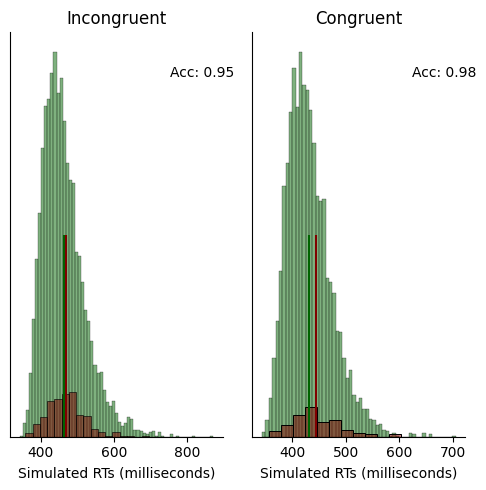

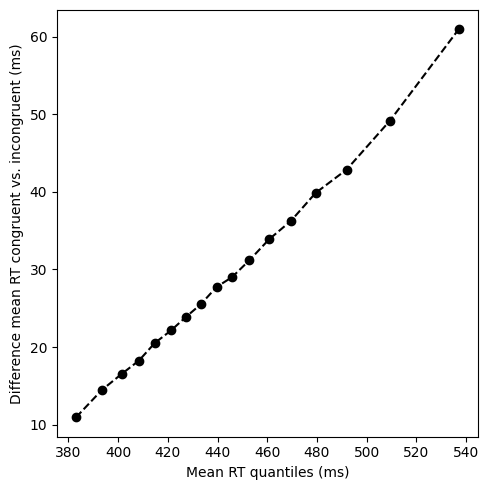

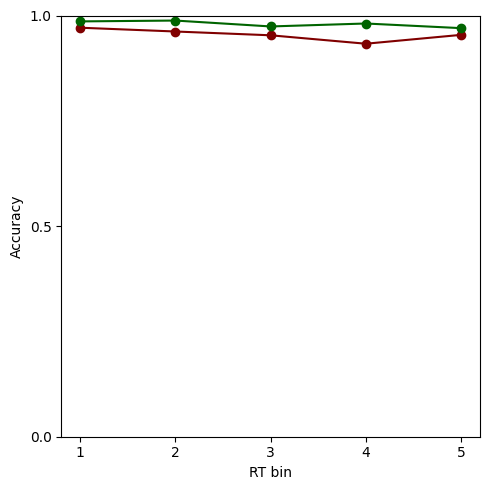

In [6]:
params = dict(
    v_congruent=np.array([1.0, 6.0]),
    v_incongruent=np.array([1.0, 6.0]),
    s_congruent=np.array([1.0, 0.7]),
    s_incongruent=np.array([1.0, 0.9]),
    b_congruent=np.array([1.0, 0.8]),
    b_incongruent=np.array([1.0, 1.0]),
    t0=0.3,
)

rdm_sims = simulate_rdm_conditions(**params)

_ = create_pushforward_plot(rdm_sims)
_ = create_delta_plot(rdm_sims)
_ = create_caf_plot(rdm_sims)

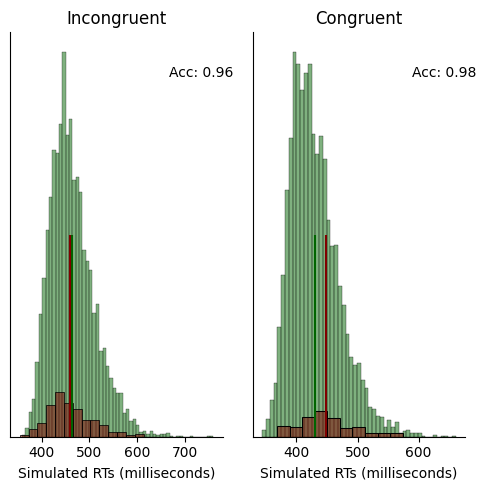

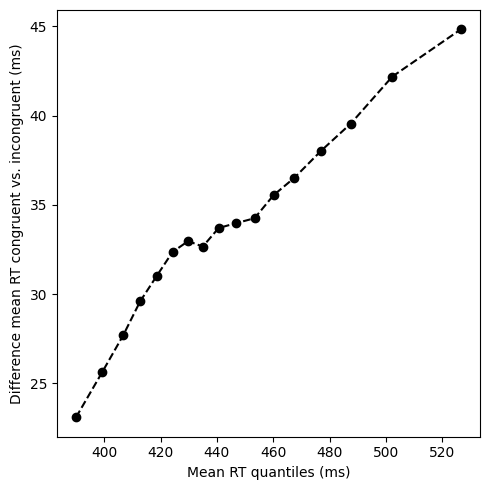

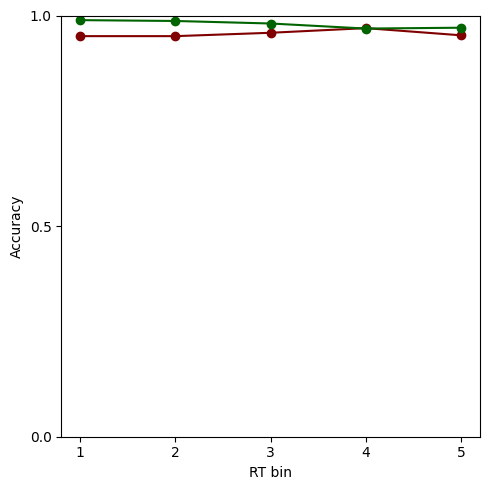

In [43]:
params = dict(
    v_congruent=np.array([1.0, 6.0]),
    v_incongruent=np.array([1.0, 6.0]),
    s_congruent=np.array([1.0, 0.7]),
    s_incongruent=np.array([1.0, 0.7]),
    b_congruent=np.array([1.0, 0.8]),
    b_incongruent=np.array([1.0, 1.0]),
    t0=0.3,
)

rdm_sims = simulate_rdm_conditions(**params)

_ = create_pushforward_plot(rdm_sims)
_ = create_delta_plot(rdm_sims)
_ = create_caf_plot(rdm_sims)

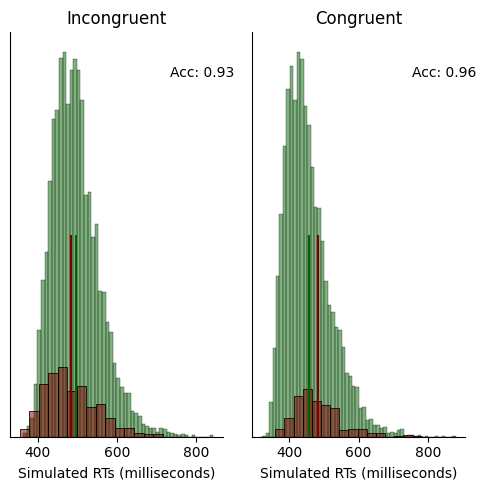

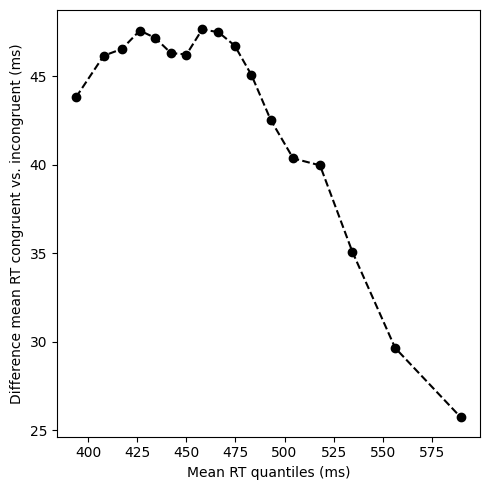

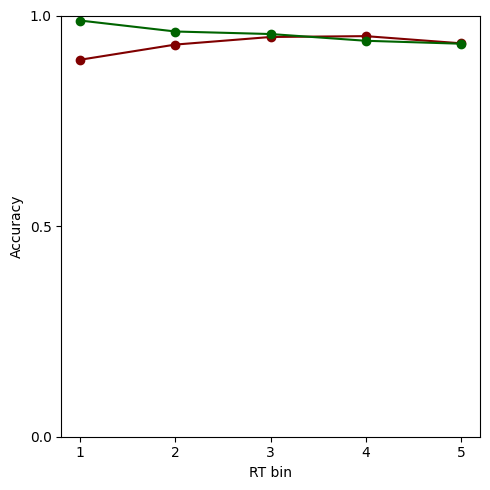

In [44]:
params = dict(
    v_congruent=np.array([1.0, 5.0]),
    v_incongruent=np.array([1.0, 5.0]),
    s_congruent=np.array([1.0, 0.9]),
    s_incongruent=np.array([1.0, 0.7]),
    b_congruent=np.array([1.0, 0.8]),
    b_incongruent=np.array([1.0, 1.0]),
    t0=0.3,
)

rdm_sims = simulate_rdm_conditions(**params)

_ = create_pushforward_plot(rdm_sims)
_ = create_delta_plot(rdm_sims)
_ = create_caf_plot(rdm_sims)

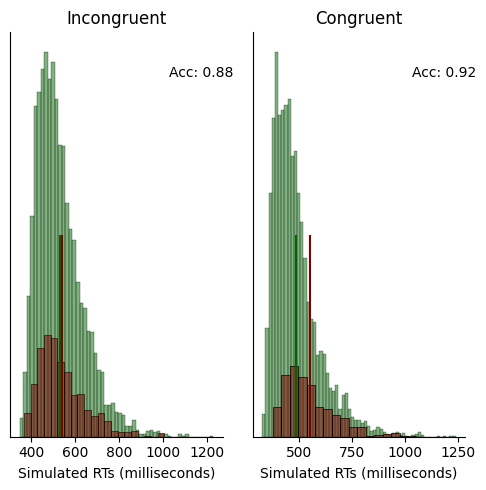

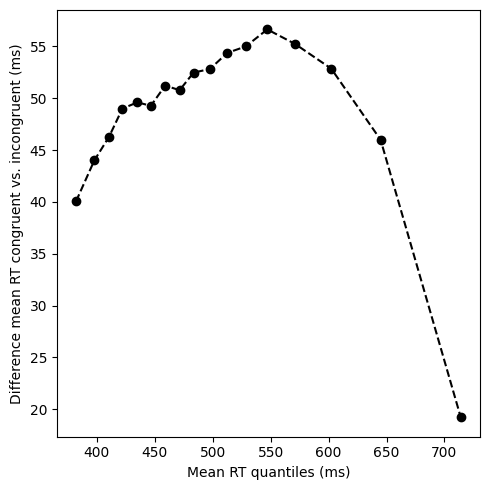

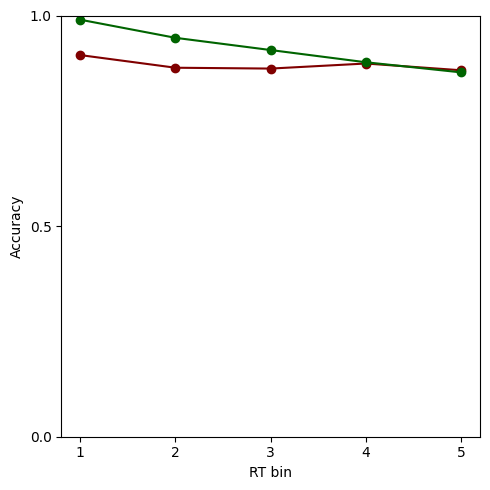

In [61]:
params = dict(
    v_congruent=np.array([1.0, 4.0]),
    v_incongruent=np.array([1.0, 4.0]),
    s_congruent=np.array([1.0, 1.2]),
    s_incongruent=np.array([1.0, 1.0]),
    b_congruent=np.array([1.0, 0.8]),
    b_incongruent=np.array([1.0, 1.0]),
    t0=0.3,
)

rdm_sims = simulate_rdm_conditions(**params)

_ = create_pushforward_plot(rdm_sims)
_ = create_delta_plot(rdm_sims)
_ = create_caf_plot(rdm_sims)